# **K-Means Clustering Assignment By Rasha**

# KMeans Clustering

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Dog Horse KMeans Challenge

In [136]:
# Import Data
df_dh = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/dog_or_horse.csv")
# We picked variables that we need
X = df_dh[['height', 'weight']]
df_dh.head()

,height,weight,target,type
0,27.0,71.0,0.0,dog
1,27.0,92.0,0.0,dog
2,32.0,47.0,0.0,dog
3,30.0,90.0,0.0,dog
4,28.0,91.0,0.0,dog


In [137]:
# Scale Data because unscaled data can lead to poor clustering results. StandardScaler standardizes features by removing the mean and scaling to unit variance.
sc = StandardScaler()
X_sc = sc.fit_transform(X)
# Fit & transform data.

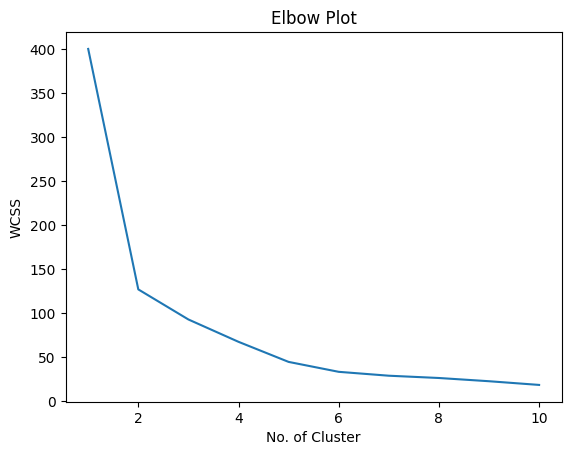

In [138]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 
# So as the k increases the inertia decreases. The point where the inertia starts to decrease at a slower rate is the optimal number of clusters.
# And we figure out that optimal No. by elbow plot.
# What this for loop does is it creates a KMeans object for each value of k from 1 to 10 and fits the model to the scaled data. It then appends the inertia (WCSS) to the wcss list. Finally, it plots the wcss against the number of clusters.
for k in range(1,11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X_sc)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Plot')
plt.xlabel('No. of Cluster')
plt.ylabel('WCSS')

plt.show()

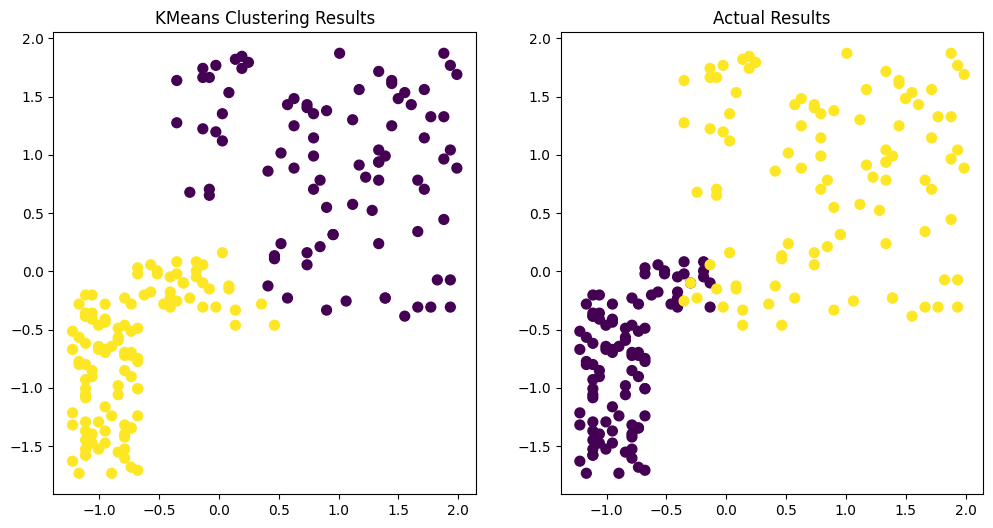

In [139]:
# Apply KMeans and Plot KMeans Results and Actual Results
kmeans = KMeans(n_clusters=2)
y_kmeans = kmeans.fit_predict(X_sc)

#KMeans Clustering Results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_sc[:, 0], X_sc[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.title('KMeans Clustering Results')

# Actual Results
plt.subplot(1, 2, 2)
plt.scatter(X_sc[:, 0], X_sc[:, 1], c=df_dh['target'], s=50, cmap='viridis')
plt.title('Actual Results')
plt.show()

In [140]:
print(y_kmeans)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0]


In [141]:
# Cluster centeriods
print (kmeans.cluster_centers_)

[[ 0.96628215  0.91732732]
 [-0.74395174 -0.70626086]]


In [142]:
# assign the y_kmeans to a new column in the dataset
df_dh['kmean_prid']= y_kmeans
df_dh

,height,weight,target,type,kmean_prid
0,27.0,71.0,0.0,dog,1
1,27.0,92.0,0.0,dog,1
2,32.0,47.0,0.0,dog,1
3,30.0,90.0,0.0,dog,1
4,28.0,91.0,0.0,dog,1
...,...,...,...,...,...
195,55.0,140.0,1.0,horse,0
196,82.0,179.0,1.0,horse,0
197,46.0,132.0,1.0,horse,0
198,56.0,89.0,1.0,horse,1


### Plot the clusters including the centroid for each of the clusters as defined by K-Means

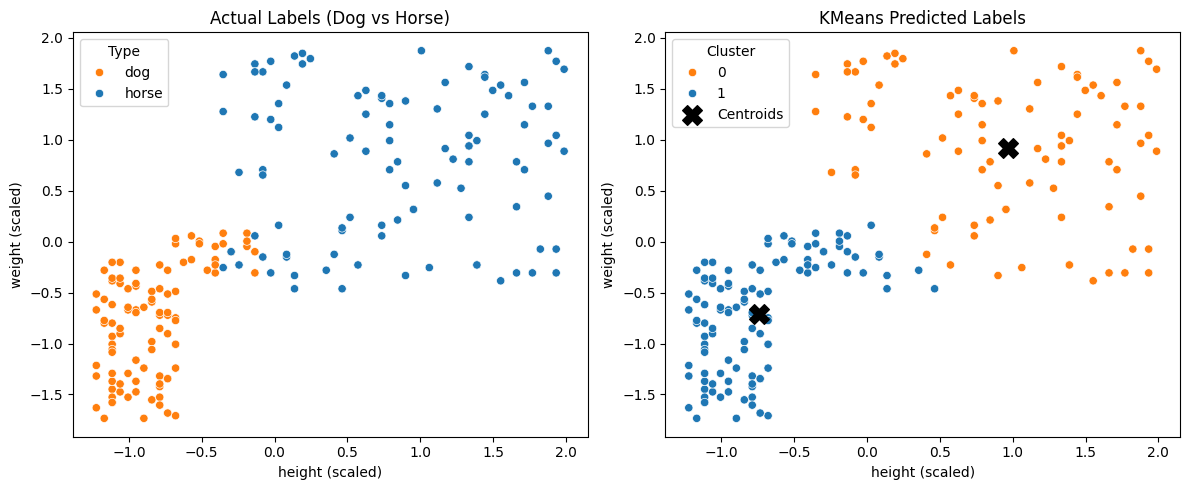

In [143]:
# Create a scatter plot of the actual results and the KMeans results
plt.figure(figsize=(12,5))

# Actual (true) labels
plt.subplot(1,2,1)
sns.scatterplot(x=X_sc[:,0], y=X_sc[:,1], hue=df_dh['type'], palette=['tab:orange','tab:blue'])
plt.title('Actual Labels (Dog vs Horse)')
plt.xlabel('height (scaled)')
plt.ylabel('weight (scaled)')
plt.legend(title='Type')

# Predicted labels from KMeans
plt.subplot(1,2,2)
sns.scatterplot(x=X_sc[:,0], y=X_sc[:,1], hue=y_kmeans, palette=['tab:orange','tab:blue'])
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], s=200, c='k', marker='X', label='Centroids')
plt.title('KMeans Predicted Labels')
plt.xlabel('height (scaled)')
plt.ylabel('weight (scaled)')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

In [144]:
# replace dog with 1 and horse with 0 to help us caluclate the Accuracy Score
df_dh['type'] = df_dh['type'].map({'dog': 1, 'horse': 0})

In [145]:
# Calculate the number of correct predictions
(df_dh['type'] == df_dh['kmean_prid']).value_counts()

True     187
False     13
Name: count, dtype: int64

In [146]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df_dh['type'], df_dh['kmean_prid'])*100

93.5

# Seattle Weather KMeans Challenge

In [205]:
df_sea = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/seattle_weather_1948-2017.csv")
X_sea = df_sea[['tmin', 'tmax']]
print(df_sea)
df_sea.head()

               ds  prcp  tmax  tmin   rain
0      1948-01-01  0.47    51    42   True
1      1948-01-02  0.59    45    36   True
2      1948-01-03  0.42    45    35   True
3      1948-01-04  0.31    45    34   True
4      1948-01-05  0.17    45    32   True
...           ...   ...   ...   ...    ...
25546  2017-12-10  0.00    49    34  False
25547  2017-12-11  0.00    49    29  False
25548  2017-12-12  0.00    46    32  False
25549  2017-12-13  0.00    48    34  False
25550  2017-12-14  0.00    50    36  False

[25551 rows x 5 columns]


,ds,prcp,tmax,tmin,rain
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [206]:
# Scale Data
sc = StandardScaler()
# Fit & transform data.
X_sea_sc = sc.fit_transform(X_sea)

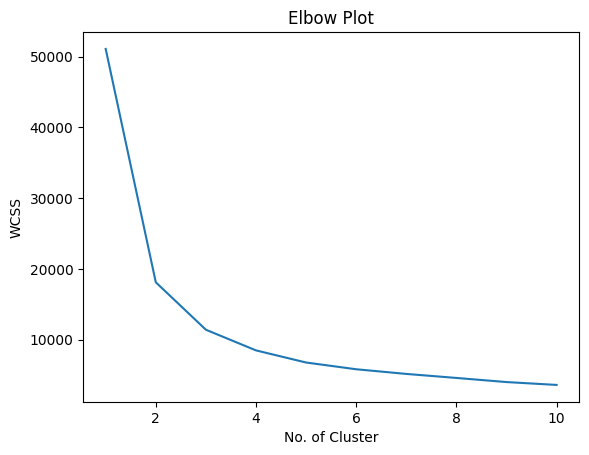

In [207]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 
for k in range(1,11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X_sea_sc)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Plot')
plt.xlabel('No. of Cluster')
plt.ylabel('WCSS')
plt.show()
# From the plot we can see that the optimal number of clusters in 4, but our target is 2 so we should pick 2.

Text(0, 0.5, 'tmin (scaled)')

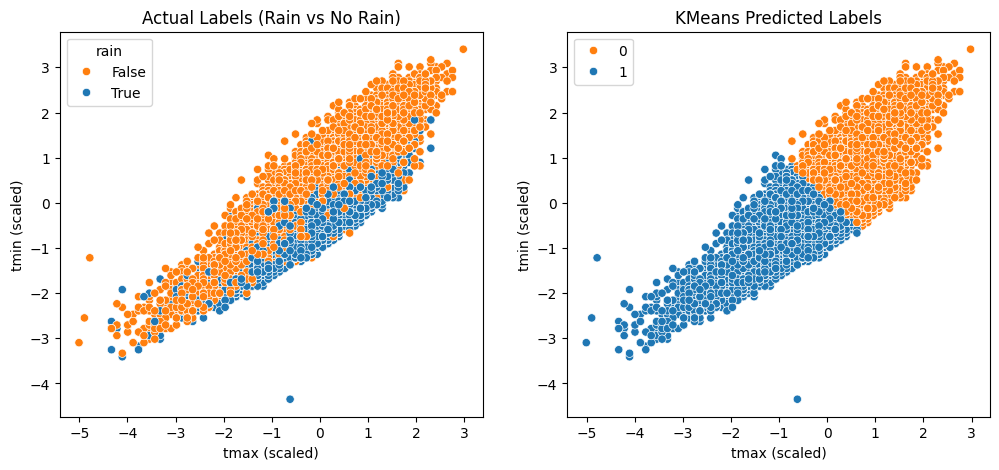

In [208]:
# Apply KMeans and Plot KMeans Results and Actual Results
kmeans = KMeans(n_clusters=2)
y_sea_kmeans = kmeans.fit_predict(X_sea_sc)

#Actual (true) labels
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=X_sea_sc[:,0], y=X_sea_sc[:,1], hue=df_sea['rain'], palette=['tab:orange','tab:blue'])
plt.title('Actual Labels (Rain vs No Rain)')
plt.xlabel('tmax (scaled)')
plt.ylabel('tmin (scaled)') 

# Predicted labels from KMeans
plt.subplot(1,2,2)
sns.scatterplot(x=X_sea_sc[:,0], y=X_sea_sc[:,1],   hue=y_sea_kmeans, palette=['tab:orange','tab:blue'])
plt.title('KMeans Predicted Labels')
plt.xlabel('tmax (scaled)')
plt.ylabel('tmin (scaled)')


In [209]:
print(y_sea_kmeans)

[1 1 1 ... 1 1 1]


In [210]:
# assign the y_kmeans to a new column
df_sea['kmean_sea_prid']= y_sea_kmeans
df_sea

,ds,prcp,tmax,tmin,rain,kmean_sea_prid
0,1948-01-01,0.47,51,42,True,1
1,1948-01-02,0.59,45,36,True,1
2,1948-01-03,0.42,45,35,True,1
3,1948-01-04,0.31,45,34,True,1
4,1948-01-05,0.17,45,32,True,1
...,...,...,...,...,...,...
25546,2017-12-10,0.00,49,34,False,1
25547,2017-12-11,0.00,49,29,False,1
25548,2017-12-12,0.00,46,32,False,1
25549,2017-12-13,0.00,48,34,False,1


In [211]:
# replace True with 1 and False with 0 to help us caluclate the Accuracy Score
df_sea['rain'] = df_sea['rain'].map({True:1, False:0})

In [212]:
# Calculate the number of correct predictions
(df_sea['rain'] == df_sea['kmean_sea_prid']).value_counts()

True     16266
False     9285
Name: count, dtype: int64

In [213]:
df_sea.dropna(subset = ['rain'], inplace=True)

In [214]:
df_sea['rain'].isna().sum()

np.int64(0)

### Plot the clusters including the centroid for each of the clusters as defined by K-Means

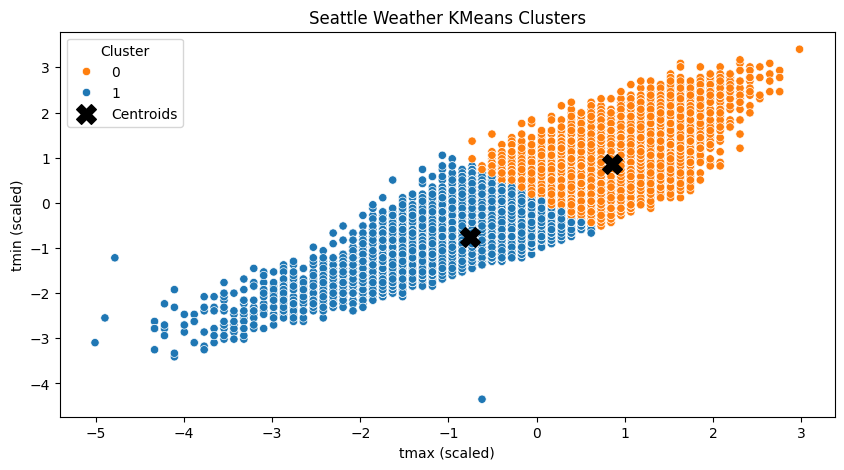

In [215]:
plt.figure(figsize=(10,5))

centroids = kmeans.cluster_centers_
sns.scatterplot(x=X_sea_sc[:,0], y=X_sea_sc[:,1], hue=y_sea_kmeans, palette=['tab:orange','tab:blue'])
plt.scatter(centroids[:,0], centroids[:,1], s=200, c='k', marker='X', label='Centroids')

plt.title('Seattle Weather KMeans Clusters')
plt.xlabel('tmax (scaled)')
plt.ylabel('tmin (scaled)')
plt.legend(title='Cluster')
plt.show()

In [216]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df_sea['rain'], df_sea['kmean_sea_prid'])*100

63.66838891498357

# Random Blob KMeans Challenge

- You dont have true labels for this data so this is truly an unsupervised dataset
- The blobs are randomly generated every time you run the cell and their characteristics are:
    - 2000-4000 data points
    - 10-30 blobs created

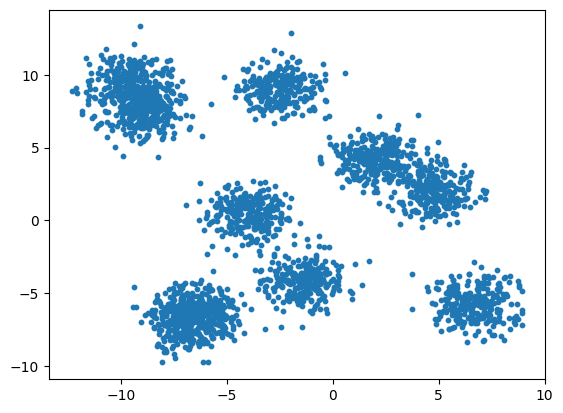

In [196]:
n_samples = np.random.randint(2000, 4000)  # Randomly choose a number of samples between 1000 and 5000
n_blobs = np.random.randint(10, 30)  # Randomly choose a number of blobs between 5 and 30
X, y = make_blobs(n_samples=n_samples, centers = n_blobs,random_state=42)
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.show()

df_blob = pd.DataFrame(X, columns=['feature1', 'feature2'])

In [197]:
# Scale Data
sc_blb = StandardScaler()
# Fit & transform data.
X_blb_sc = sc.fit_transform(df_blob)

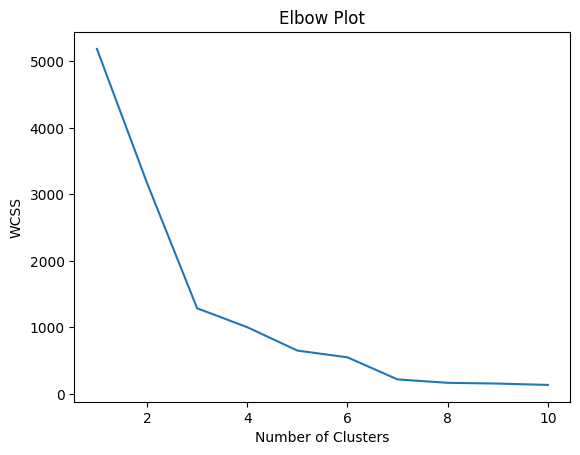

In [198]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 
for k in range(1,n_blobs+1):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X_blb_sc)
    wcss.append(km.inertia_)

plt.plot(range(1,n_blobs+1),wcss)
plt.title('Elbow Plot')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


Text(0, 0.5, '1')

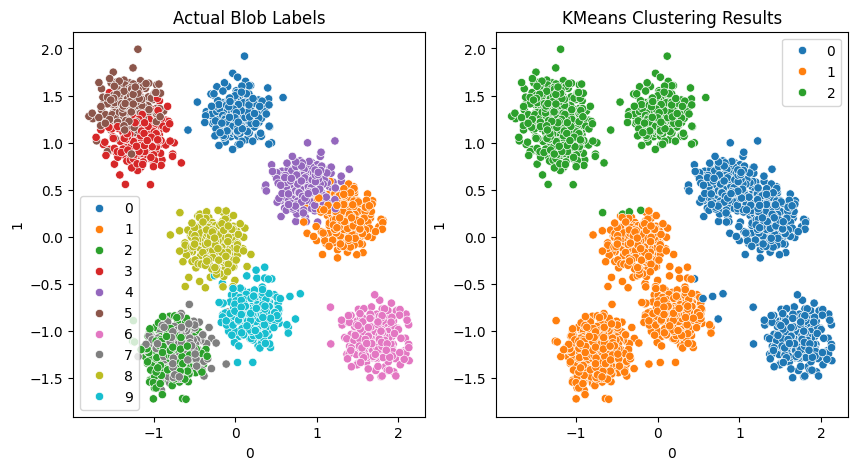

In [199]:
# Apply KMeans and Plot KMeans Results and Actual Results
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_blb_kmeans = kmeans.fit_predict(X_blb_sc)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.scatterplot(x=X_blb_sc[:,0], y=X_blb_sc[:,1], hue=y, palette='tab10')
plt.title('Actual Blob Labels')
plt.xlabel('0')
plt.ylabel('1')

plt.subplot(1,2,2)
sns.scatterplot(x=X_blb_sc[:,0], y=X_blb_sc[:,1], hue=y_blb_kmeans, palette='tab10')
plt.title('KMeans Clustering Results')
plt.xlabel('0')
plt.ylabel('1')

In [200]:
print(y_blb_kmeans)

[0 0 1 ... 1 2 1]


Text(0, 0.5, '1')

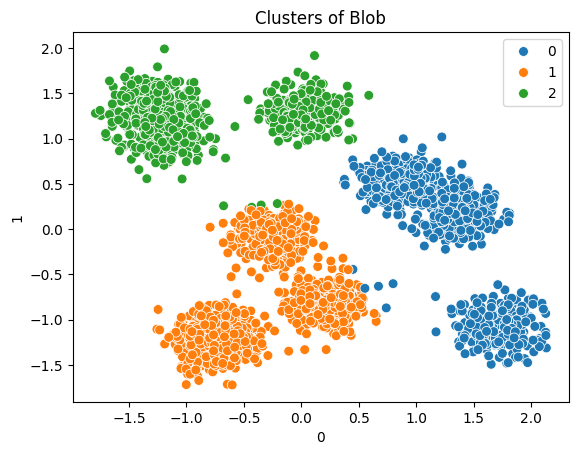

In [201]:
# Plot the clusters 
sns.scatterplot(x=X_blb_sc[:,0], y=X_blb_sc[:,1],s=50, hue=y_blb_kmeans, palette='tab10')
plt.title('Clusters of Blob')
plt.xlabel('0')
plt.ylabel('1')